<a href="https://colab.research.google.com/github/pineapple-bits/mercedes-regression-pipeline/blob/main/mercedes_manufacturing_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4204,8405,107.39,ak,s,as,c,d,aa,d,q,...,1,0,0,0,0,0,0,0,0,0
4205,8406,108.77,j,o,t,d,d,aa,h,h,...,0,1,0,0,0,0,0,0,0,0
4206,8412,109.22,ak,v,r,a,d,aa,g,e,...,0,0,1,0,0,0,0,0,0,0
4207,8415,87.48,al,r,e,f,d,aa,l,u,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Generate expected column names from X0 to X385
expected_cols = [f'X{i}' for i in range(386)]

# Get the actual column names from the DataFrame, excluding 'ID' and 'y'
actual_x_cols = [col for col in df.columns if col.startswith('X')]

# Find the missing columns
missing_cols = list(set(expected_cols) - set(actual_x_cols))

print("Missing 'X' columns:", missing_cols)

Missing 'X' columns: ['X381', 'X121', 'X9', 'X72', 'X25', 'X303', 'X149', 'X7', 'X193', 'X188']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 378 entries, ID to X385
dtypes: float64(1), int64(369), object(8)
memory usage: 12.1+ MB


In [ ]:
df.describe()

,ID,y,X10,X11,X12,X13,X14,X15,X16,X17,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
count,4209.000000,4209.000000,4209.000000,4209.0,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,...,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000
mean,4205.960798,100.669318,0.013305,0.0,0.075077,0.057971,0.428130,0.000475,0.002613,0.007603,...,0.318841,0.057258,0.314802,0.020670,0.009503,0.008078,0.007603,0.001663,0.000475,0.001426
std,2437.608688,12.679381,0.114590,0.0,0.263547,0.233716,0.494867,0.021796,0.051061,0.086872,...,0.466082,0.232363,0.464492,0.142294,0.097033,0.089524,0.086872,0.040752,0.021796,0.037734
min,0.000000,72.110000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2095.000000,90.820000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4220.000000,99.150000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6314.000000,109.010000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8417.000000,265.320000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


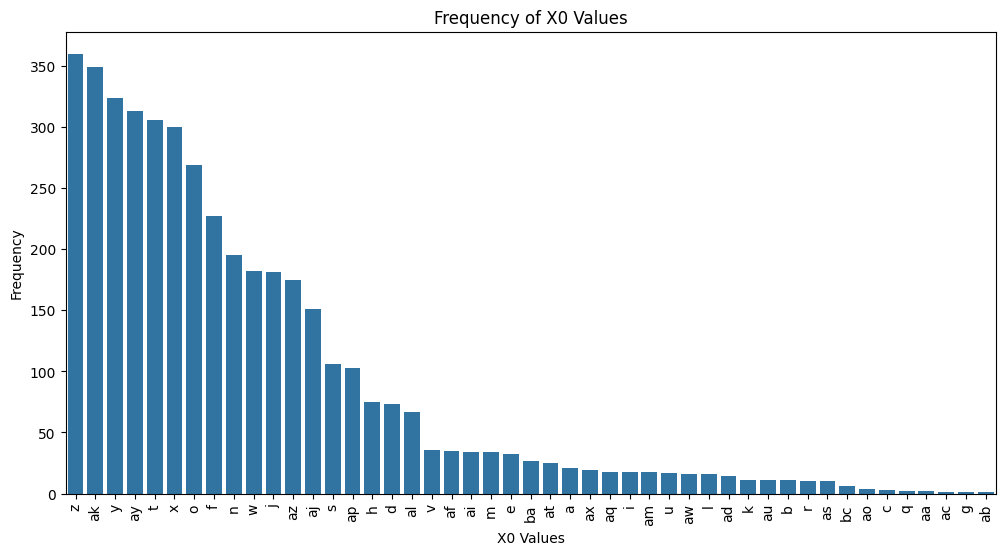

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the frequency of each value in 'X0'
x0_counts = df['X0'].value_counts()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=x0_counts.index, y=x0_counts.values)
plt.title('Frequency of X0 Values')
plt.xlabel('X0 Values')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

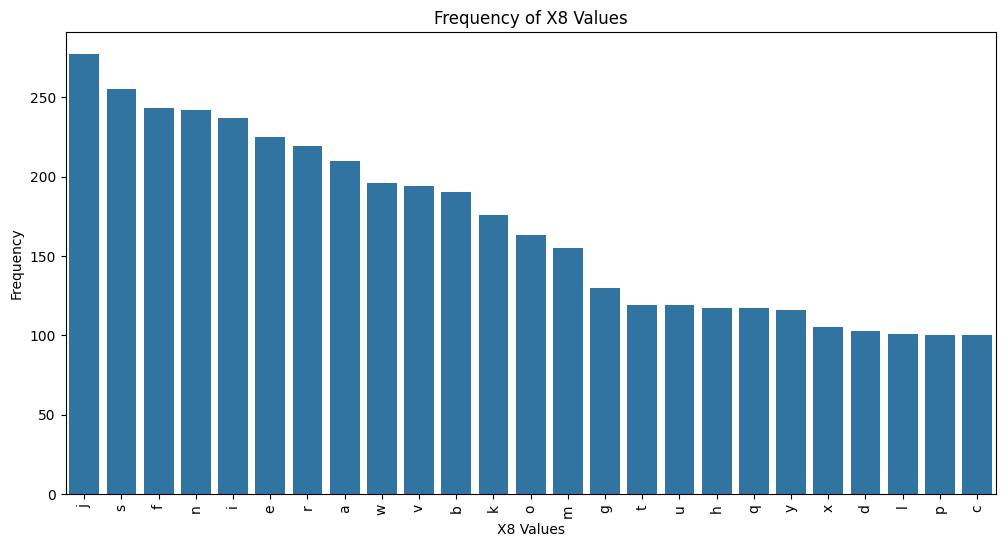

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the frequency of each value in 'X0'
x8_counts = df['X8'].value_counts()

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=x8_counts.index, y=x8_counts.values)
plt.title('Frequency of X8 Values')
plt.xlabel('X8 Values')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Check for binary columns
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and all(df[col].isin([0, 1]))]

print(f"Number of binary variables: {len(binary_cols)}")
print("Binary variable names:", binary_cols)

Number of binary variables: 356
Binary variable names: ['X10', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119', 'X120', 'X122', 'X123', 'X124', 'X125', 'X126', 'X127', 'X128', 'X129', 'X130', 'X131', 'X132', 'X133', 'X134', 'X135', 'X136', 'X137', 'X138', 'X139', 'X140', 'X141', 'X142', 'X143', 'X144'

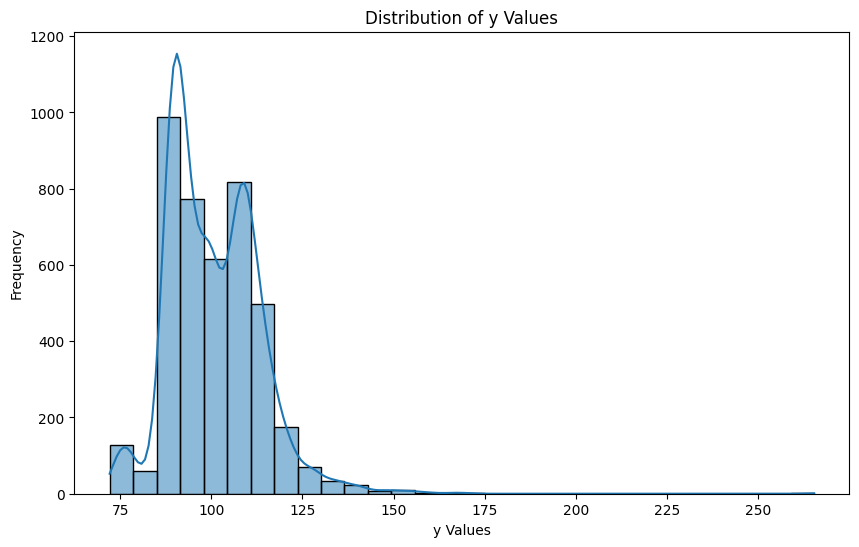

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of 'y' values
plt.figure(figsize=(10, 6))
sns.histplot(df['y'], kde=True, bins=30)
plt.title('Distribution of y Values')
plt.xlabel('y Values')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4204,8405,107.39,ak,s,as,c,d,aa,d,q,...,1,0,0,0,0,0,0,0,0,0
4205,8406,108.77,j,o,t,d,d,aa,h,h,...,0,1,0,0,0,0,0,0,0,0
4206,8412,109.22,ak,v,r,a,d,aa,g,e,...,0,0,1,0,0,0,0,0,0,0
4207,8415,87.48,al,r,e,f,d,aa,l,u,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# from sklearn.preprocessing import LabelEncoder
# # Select object type columns (strings)
string_cols = df.select_dtypes(include='object').columns

# # Create a copy to avoid modifying the original DataFrame
# df_encoded = df.copy()

# # Perform label encoding (convert catagorical data to numerical data)
# for col in string_cols:
#     le = LabelEncoder()
#     df_encoded[col] = le.fit_transform(df_encoded[col])

# # Display the first few rows of the encoded DataFrame

# display(df_encoded.head())

In [ ]:
df_binary = df[['X314', 'X263', 'X136', 'X261']]
df_binary = df_binary.sum(axis=1)
df['sums'] = df_binary
df.head()

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X376,X377,X378,X379,X380,X382,X383,X384,X385,sums
0,0,130.81,k,v,at,a,d,u,j,o,...,0,1,0,0,0,0,0,0,0,2
1,6,88.53,k,t,av,e,d,y,l,o,...,0,0,0,0,0,0,0,0,0,2
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,1,0,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_fencoded = df.copy()
for col in string_cols:
  frequency_map = df[col].value_counts(normalize=True).to_dict()
  df_fencoded[col] = df_fencoded[col].map(frequency_map)
display(df_fencoded.head())

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X376,X377,X378,X379,X380,X382,X383,X384,X385,sums
0,0,130.81,0.002613,0.096935,0.001426,0.104538,0.99905,0.000238,0.246852,0.038727,...,0,1,0,0,0,0,0,0,0,2
1,6,88.53,0.002613,0.007365,0.000950,0.038727,0.99905,0.000238,0.113566,0.038727,...,0,0,0,0,0,0,0,0,0,2
2,7,76.26,0.041578,0.012354,0.032549,0.461392,0.99905,0.000475,0.246852,0.024947,...,0,0,0,0,0,1,0,0,0,0
3,9,80.62,0.041578,0.007365,0.032549,0.255643,0.99905,0.000475,0.113566,0.053457,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,0.041578,0.096935,0.032549,0.255643,0.99905,0.000238,0.148491,0.057496,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# Create a copy of the original DataFrame to apply KFold Mean Encoding
df_kencoded = df.copy()

# The 'string_cols' variable is already defined from previous steps
# string_cols = df_kencoded.select_dtypes(include='object').columns # Re-run if string_cols is not defined

# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Create new columns for the KFold Mean Encoded features
for col in string_cols:
    df_kencoded[f'{col}_MeanEncoded'] = np.nan

    # Calculate overall mean for handling unseen categories in validation set
    overall_mean = df_kencoded['y'].mean()

    for fold, (train_idx, val_idx) in enumerate(kf.split(df_kencoded)):
        X_train_fold, X_val_fold = df_kencoded.iloc[train_idx], df_kencoded.iloc[val_idx]

        # Calculate mean of 'y' for each category in the training fold
        mean_target = X_train_fold.groupby(col)['y'].mean()

        # Apply mean encoding to the validation fold
        df_kencoded.loc[val_idx, f'{col}_MeanEncoded'] = X_val_fold[col].map(mean_target)

    # Fill any NaN values (categories present in validation but not in training fold)
    # with the overall mean, after all folds are processed.
    df_kencoded[f'{col}_MeanEncoded'] = df_kencoded[f'{col}_MeanEncoded'].fillna(overall_mean)

# Drop original string columns
df_kencoded = df_kencoded.drop(columns=string_cols)

# Display the first few rows of the DataFrame with KFold Mean Encoding
df_kencoded.head()

,ID,y,X10,X11,X12,X13,X14,X15,X16,X17,...,X385,sums,X0_MeanEncoded,X1_MeanEncoded,X2_MeanEncoded,X3_MeanEncoded,X4_MeanEncoded,X5_MeanEncoded,X6_MeanEncoded,X8_MeanEncoded
0,0,130.81,0,0,0,1,0,0,0,0,...,0,2,97.218889,101.311682,101.467500,102.179284,100.419842,100.669318,100.813871,97.764308
1,6,88.53,0,0,0,0,0,0,0,0,...,0,2,100.031250,93.847778,97.836667,100.038527,100.701103,100.669318,98.360472,98.189841
2,7,76.26,0,0,0,0,0,0,0,1,...,0,0,78.289852,96.035641,84.277453,102.144746,100.871017,100.669318,101.257322,98.102658
3,9,80.62,0,0,0,0,0,0,0,0,...,0,0,78.289852,95.160800,84.277453,96.864313,100.871017,100.669318,99.323979,105.389457
4,13,78.02,0,0,0,0,0,0,0,0,...,0,0,77.833214,101.255596,82.342411,96.665408,100.701103,100.669318,101.264286,101.437071


In [ ]:
df_kencoded['X0_MeanEncoded']

,X0_MeanEncoded
0,97.218889
1,100.031250
2,78.289852
3,78.289852
4,77.833214
...,...
4204,112.418674
4205,111.924306
4206,112.459075
4207,93.491607


In [ ]:
from sklearn.decomposition import PCA, FastICA
n_comp = 12
pca = PCA(n_components=n_comp, random_state=42)
ica = FastICA(n_components=n_comp, random_state=42)
pca_results = pca.fit_transform(df_kencoded.drop('y', axis=1))
ica_results = ica.fit_transform(df_kencoded.drop('y', axis=1))
for i in range(n_comp):
  df_kencoded[f'pca_{i}'] = pca_results[:, i]
  df_kencoded[f'ica_{i}'] = ica_results[:, i]
df_kencoded.head()

,ID,y,X10,X11,X12,X13,X14,X15,X16,X17,...,pca_7,ica_7,pca_8,ica_8,pca_9,ica_9,pca_10,ica_10,pca_11,ica_11
0,0,130.81,0,0,0,1,0,0,0,0,...,2.836638,1.734872,-0.883680,0.132401,-0.284829,0.031774,-1.130843,1.358385,-0.990533,-0.651065
1,6,88.53,0,0,0,0,0,0,0,0,...,-0.129848,1.650766,-3.182877,-2.531209,0.371810,-0.980251,-1.004423,1.225638,0.480154,0.339037
2,7,76.26,0,0,0,0,0,0,0,1,...,1.661674,1.652085,-1.285903,-2.298670,-4.115178,-0.252363,0.090319,1.253930,-1.761663,-4.654911
3,9,80.62,0,0,0,0,0,0,0,0,...,0.463712,1.422408,-1.913558,-2.273215,-3.984524,0.057513,0.146068,1.112519,-2.196637,-4.458823
4,13,78.02,0,0,0,0,0,0,0,0,...,1.329848,1.604677,-0.037626,0.057671,-4.206974,-0.033790,-0.110591,1.292317,-2.491457,-5.185502


In [ ]:
df_kencoded.describe() # Gives statistics about all the columns

,ID,y,X10,X11,X12,X13,X14,X15,X16,X17,...,pca_7,ica_7,pca_8,ica_8,pca_9,ica_9,pca_10,ica_10,pca_11,ica_11
count,4209.000000,4209.000000,4209.000000,4209.0,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,4209.000000,...,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03,4.209000e+03
mean,4205.960798,100.669318,0.013305,0.0,0.075077,0.057971,0.428130,0.000475,0.002613,0.007603,...,4.473600e-16,-2.052792e-15,1.373817e-14,3.342539e-16,-5.300794e-15,-3.098601e-15,-2.163534e-14,1.123633e-14,-7.968072e-16,-1.559851e-15
std,2437.608688,12.679381,0.114590,0.0,0.263547,0.233716,0.494867,0.021796,0.051061,0.086872,...,1.430602e+00,1.000119e+00,1.331909e+00,1.000119e+00,1.222307e+00,1.000119e+00,1.168361e+00,1.000119e+00,1.136076e+00,1.000119e+00
min,0.000000,72.110000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.536040e+00,-2.359622e+00,-7.321884e+00,-9.430094e+00,-5.010894e+00,-8.612706e+00,-4.753007e+00,-4.742678e+00,-4.354664e+00,-5.301110e+00
25%,2095.000000,90.820000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-9.753762e-01,-7.914451e-01,-7.065878e-01,-2.200229e-01,-5.826081e-01,-5.535648e-01,-8.999618e-01,-7.622371e-01,-8.082780e-01,-1.414342e-01
50%,4220.000000,99.150000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-6.371613e-03,-4.030891e-02,6.010938e-02,-2.823126e-02,9.973863e-02,-7.247758e-02,-7.401594e-02,1.095465e-02,4.538508e-02,1.740946e-01
75%,6314.000000,109.010000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,8.473239e-01,9.831084e-01,8.006983e-01,1.928902e-01,7.304192e-01,6.024799e-01,8.372631e-01,8.254660e-01,7.506170e-01,4.624120e-01
max,8417.000000,265.320000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,6.380319e+00,2.367996e+00,9.185925e+00,4.308150e+00,3.287263e+00,3.873876e+00,5.540518e+00,3.703788e+00,2.945175e+00,1.724009e+00


In [ ]:
df_kencoded.corr() # Calculates correlation coefficiant between every variable (1 means linearly dependent with a positive coefficient, very correlated, -1 means linealrly dependent with a negative coefficient, also heavily correlated, 0 means no correlation)

,ID,y,X10,X11,X12,X13,X14,X15,X16,X17,...,pca_7,ica_7,pca_8,ica_8,pca_9,ica_9,pca_10,ica_10,pca_11,ica_11
ID,1.000000e+00,-0.055108,0.001602,NaN,0.058988,-0.031917,-0.025438,0.002237,-0.036480,-0.038171,...,2.763989e-09,-9.832871e-01,2.181234e-08,3.107796e-02,3.642326e-08,-2.417748e-02,1.339296e-07,-1.388035e-01,3.760457e-09,-3.577602e-02
y,-5.510772e-02,1.000000,-0.026985,NaN,0.089792,0.048276,0.193643,0.023116,0.048946,-0.159815,...,9.865976e-03,6.416771e-02,-4.386886e-04,1.346352e-01,-1.151145e-03,-3.830250e-01,3.795373e-02,-3.959974e-02,2.421267e-02,3.388651e-01
X10,1.602168e-03,-0.026985,1.000000,NaN,-0.033084,-0.028806,-0.100474,-0.002532,-0.005944,-0.010164,...,-6.517454e-02,6.078236e-03,-5.365957e-02,-3.146600e-03,3.116605e-02,-1.350048e-02,-3.099445e-03,1.074255e-03,-8.839030e-02,-2.509358e-02
X11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X12,5.898826e-02,0.089792,-0.033084,NaN,1.000000,0.214825,-0.246513,-0.006212,-0.014584,-0.024937,...,4.242752e-02,-6.003780e-02,-4.557744e-02,-2.721361e-02,-1.809445e-02,5.922929e-03,-2.583669e-03,4.374623e-03,9.194938e-02,9.413517e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ica_9,-2.417748e-02,-0.383025,-0.013500,NaN,0.005923,-0.013985,0.328961,-0.035756,0.010027,0.129460,...,-2.593105e-01,-1.762667e-17,8.062620e-02,7.842022e-16,-1.405547e-02,1.000000e+00,2.441061e-02,-1.653395e-15,-7.718849e-02,6.203130e-16
pca_10,1.339296e-07,0.037954,-0.003099,NaN,-0.002584,-0.008432,0.058981,0.012747,0.002135,0.099902,...,-1.100244e-13,1.380844e-01,2.980320e-13,-5.420634e-02,3.004786e-13,2.441061e-02,1.000000e+00,-9.447415e-01,-8.617941e-14,-2.021455e-01
ica_10,-1.388035e-01,-0.039600,0.001074,NaN,0.004375,0.010727,-0.010239,-0.008079,0.008237,-0.000135,...,6.638812e-03,7.929034e-17,-9.063637e-02,1.394251e-15,-2.774363e-01,-1.653395e-15,-9.447415e-01,1.000000e+00,-1.912977e-02,1.502850e-16
pca_11,3.760457e-09,0.024213,-0.088390,NaN,0.091949,0.128301,0.064707,0.005405,0.026617,0.022021,...,-3.625686e-14,-3.855374e-02,-1.109735e-13,-1.264534e-01,-4.132457e-14,-7.718849e-02,-8.617941e-14,-1.912977e-02,1.000000e+00,3.813242e-01


In [ ]:
df_kencoded['X0_MeanEncoded']

,X0_MeanEncoded
0,97.218889
1,100.031250
2,78.289852
3,78.289852
4,77.833214
...,...
4204,112.418674
4205,111.924306
4206,112.459075
4207,93.491607


In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_kencoded.corr()

# Get the correlations with 'y' and sort them
# This is to see which variables have the highest correlation together to try finidning variables for applying linear regression
y_correlations = correlation_matrix['y'].sort_values(ascending=False)

# Display the correlations
print("Correlations with 'y':")
print(y_correlations)

Correlations with 'y':
y                 1.000000
X0_MeanEncoded    0.749281
pca_1             0.734489
sums              0.657075
X314              0.606005
                    ...   
X290                   NaN
X293                   NaN
X297                   NaN
X330                   NaN
X347                   NaN
Name: y, Length: 403, dtype: float64


In [ ]:
# Identify columns with zero variance
zero_variance_cols = df_kencoded.columns[df_kencoded.var() == 0]

print("Columns with zero variance (will result in NaN correlations):")
print(zero_variance_cols)

Columns with zero variance (will result in NaN correlations):
Index(['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X289', 'X290', 'X293',
       'X297', 'X330', 'X347'],
      dtype='object')


In [ ]:
import pandas as pd

df_kencoded = df_kencoded.drop(columns=zero_variance_cols) # Drop the columns with zero correlation since there is no point in putting them in the linear regression becuase 0 dependence
# Calculate the correlation matrix
correlation_matrix = df_kencoded.corr()

# Get the correlations with 'y' and sort them
# This is to see which variables have the highest correlation together to try finidning variables for applying linear regression
y_correlations = correlation_matrix['y'].sort_values(ascending=False)

# Set display options to show all rows in the Series
pd.set_option('display.max_rows', None)

# Display the correlations
print("Correlations with 'y':")
print(y_correlations)

# Reset display options to default after printing
pd.reset_option('display.max_rows')

Correlations with 'y':
y                 1.000000
X0_MeanEncoded    0.749281
pca_1             0.734489
sums              0.657075
X314              0.606005
X261              0.588785
X2_MeanEncoded    0.453856
ica_6             0.452657
X263              0.379629
X136              0.368177
ica_11            0.338865
X275              0.275042
X119              0.272728
X118              0.272728
ica_2             0.239717
X51               0.229999
X264              0.228169
X126              0.223975
X179              0.218034
X130              0.216763
X311              0.210318
X66               0.201035
X198              0.195290
X251              0.194882
X191              0.194882
X113              0.194418
X147              0.194418
X134              0.194418
X222              0.194418
X48               0.194418
X3_MeanEncoded    0.194207
X14               0.193643
X315              0.190009
X306              0.188276
X52               0.185480
X224              0.184292
X170 

In [ ]:
df_kencoded['X0_MeanEncoded']

,X0_MeanEncoded
0,97.218889
1,100.031250
2,78.289852
3,78.289852
4,77.833214
...,...
4204,112.418674
4205,111.924306
4206,112.459075
4207,93.491607


In [ ]:
df_kencoded.head()

,ID,y,X10,X12,X13,X14,X15,X16,X17,X18,...,pca_7,ica_7,pca_8,ica_8,pca_9,ica_9,pca_10,ica_10,pca_11,ica_11
0,0,130.81,0,0,1,0,0,0,0,1,...,2.836638,1.734872,-0.883680,0.132401,-0.284829,0.031774,-1.130843,1.358385,-0.990533,-0.651065
1,6,88.53,0,0,0,0,0,0,0,1,...,-0.129848,1.650766,-3.182877,-2.531209,0.371810,-0.980251,-1.004423,1.225638,0.480154,0.339037
2,7,76.26,0,0,0,0,0,0,1,0,...,1.661674,1.652085,-1.285903,-2.298670,-4.115178,-0.252363,0.090319,1.253930,-1.761663,-4.654911
3,9,80.62,0,0,0,0,0,0,0,0,...,0.463712,1.422408,-1.913558,-2.273215,-3.984524,0.057513,0.146068,1.112519,-2.196637,-4.458823
4,13,78.02,0,0,0,0,0,0,0,0,...,1.329848,1.604677,-0.037626,0.057671,-4.206974,-0.033790,-0.110591,1.292317,-2.491457,-5.185502


In [ ]:
df_kencoded = df_kencoded[df_kencoded['y'] < 175]
X = df_kencoded.drop('y', axis=1)# Define the X variable of the space you're working in, here testing with the two most correlated variables to y
Y = df_kencoded['y'] # Define the output Y as y
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2) # Example for degree 2


In [ ]:
from sklearn.model_selection import train_test_split # This is a tool avaliable in the sk-learn library
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 42) # using this we split our workspace data into two pieces (here 0.2 implies 20%), where 20% is used as test data, and the other 80% is used as train data to train the model on

In [ ]:
# from sklearn.linear_model import LinearRegression # We import the linear regression model from sklearn and run it on our selected data
# model = LinearRegression()
# model.fit(X_train, Y_train)

In [ ]:
import xgboost as xgb
xgb = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=90,
                         gamma=0.1,
                         learning_rate=0.02,
                         reg_alpha=1.5,
                         reg_lambda=2,
                         max_depth=3,
                         random_state=42)
xgb.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=90,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=80,  # Similar to n_estimators
    learning_rate=0.03,
    depth=3,          # Similar to max_depth
    loss_function='RMSE',
    random_seed=42,
    verbose=False     # Suppress verbose output during training
)

cat.fit(X_train, Y_train)


In [ ]:
import lightgbm as lgb
lgbm = lgb.LGBMRegressor(objective='regression',
                            metric='rmse',
                            n_estimators=80,
                            learning_rate=0.03,
                            num_leaves=15,
                            random_state=42)
lgbm.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7609
[LightGBM] [Info] Number of data points in the train set: 3366, number of used features: 289
[LightGBM] [Info] Start training from score 100.688779


LGBMRegressor(learning_rate=0.03, metric='rmse', n_estimators=80, num_leaves=15,
              objective='regression', random_state=42)

In [ ]:
Y_pred = 0.6*cat.predict(X_test) + 0.4*xgb.predict(X_test) # These are the values predicted by the trained model on the test X data

In [ ]:
ss_res = ((Y_test - Y_pred) ** 2).sum()
ss_tot = ((Y_test - Y_test.mean()) ** 2).sum()
r2_manual = 1 - ss_res / ss_tot
print("Manual R²:", r2_manual) # Calculating the R^2 value of the prediction

Manual R²: 0.5634464919220519


In [ ]:
mae = (abs(Y_test - Y_pred)).mean()
print("MAE:", mae) # Calculating the Mean Absolute Error of the prediction

MAE: 5.509473530616454


In [ ]:
import numpy as np
rmse = np.sqrt(((Y_test - Y_pred) ** 2).mean())
print("RMSE:", rmse) # Calculating the Root Mean Squared Error of the prediction

RMSE: 8.276481495097176


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np


scores = cross_val_score(cat, X, Y, cv=5, scoring='r2')

cv_score = np.mean(scores)
print(f"CV: {cv_score:.4f}")

CV: 0.5791


In [ ]:
# !pip install bayesian-optimization

In [ ]:
test_df = pd.read_csv('/content/test.csv') # Loading the provided test data

In [ ]:
string_cols_train = df.select_dtypes(include='object').columns

# Create overall mean from training data for unseen categories
overall_train_mean = df['y'].mean()

# Create a dictionary to store mean encoding maps for each categorical column from training data
train_mean_encoding_maps = {}
for col in string_cols_train:
    train_mean_encoding_maps[col] = df.groupby(col)['y'].mean().to_dict()

test_df_processed = test_df.copy()

# Handle the 'sums' column for the test set
if all(col in test_df_processed.columns for col in ['X314', 'X261', 'X263']):
    test_df_binary_sum = test_df_processed[['X314', 'X261', 'X263']].sum(axis=1)
    test_df_processed['sums'] = test_df_binary_sum
else:
    print("Warning: One or more columns for 'sums' calculation (X314, X261, X263) are missing in test_df.")
    test_df_processed['sums'] = 0


for col in string_cols_train:
    if col in test_df_processed.columns:
        test_df_processed[f'{col}_MeanEncoded'] = test_df_processed[col].map(train_mean_encoding_maps[col])
        test_df_processed[f'{col}_MeanEncoded'].fillna(overall_train_mean, inplace=True)
    else:
        # If a string column from training is not in test, create a column filled with overall mean
        test_df_processed[f'{col}_MeanEncoded'] = overall_train_mean

test_df_processed=test_df_processed.drop(string_cols, axis=1)
test_df_processed.head()
# Drop original string columns from test_df_processed
# test_df_processed = test_df_processed.drop(columns=string_cols_train, errors='ignore')


# Apply PCA and ICA transforms
pca_results_test = pca.transform(test_df_processed)
ica_results_test = ica.transform(test_df_processed)

for i in range(n_comp):
    test_df_processed[f'pca_{i}'] = pca_results_test[:, i]
    test_df_processed[f'ica_{i}'] = ica_results_test[:, i]

# Drop zero variance columns (identified from training data)
test_df_processed = test_df_processed.drop(columns=zero_variance_cols, errors='ignore')

# Ensure test_df_final has the same columns as the training features (X)
train_features = X.columns

missing_in_test = set(train_features) - set(test_df_processed.columns)
for col in missing_in_test:
    test_df_processed[col] = 0

extra_in_test = set(test_df_processed.columns) - set(train_features)
test_df_processed = test_df_processed.drop(columns=list(extra_in_test))

test_df_final = test_df_processed[train_features]

# Make predictions
Y_test_pred_final = 0.6*cat.predict(test_df_final) + 0.4*xgb.predict(test_df_final)

submission_df = pd.DataFrame({'ID': test_df['ID'], 'y': Y_test_pred_final})

submission_df.to_csv('submission.csv', index=False)

print("Predictions saved to submission.csv")

/tmp/ipython-input-3872662113.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df_processed[f'{col}_MeanEncoded'].fillna(overall_train_mean, inplace=True)
/tmp/ipython-input-3872662113.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

Predictions saved to submission.csv


In [ ]:
# from bayes_opt import BayesianOptimization
# def xgb_evaluate(max_depth, learning_rate, n_estimators, gamma, reg_alpha, reg_lambda):
#   model = xgb.XGBRegressor(objective='reg:squarederror',
#                          n_estimators=int(n_estimators),
#                          gamma=gamma,
#                          learning_rate=learning_rate,
#                          max_depth=int(max_depth),
#                          random_state=42,
#                          reg_alpha=reg_alpha,
#                          reg_lambda=reg_lambda)
#   scores = cross_val_score(model, X, Y, cv=5, scoring='r2')
#   cv_score = np.mean(scores)
#   return cv_score

# xgb_bo.maximize(init_points=20, n_iter=100)

# # 5. Extract Best Parameters
# best_params = xgb_bo.max['params']
# best_params['max_depth'] = int(best_params['max_depth'])
# # min_child_weight was not part of pbounds, so this line would cause an error.
# # If you intend to optimize min_child_weight, add it to pbounds.
# # best_params['min_child_weight'] = int(best_params['min_child_weight'])

# print("\n--- Best Parameters Found ---")
# print(best_params)